Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

- Deep Learning is a branch of Artificial Intelligence (AI) and Machine Learning (ML) that uses artificial neural networks with multiple hidden layers to automatically learn patterns and features from large amounts of data. Unlike traditional machine learning, which often requires manual feature engineering, deep learning learns relevant features directly from raw data such as images, text, audio, and videos. It evolved from the concept of artificial neural networks introduced in the 1940s, but gained popularity after 2006 due to improvements in computing power, availability of large datasets, and advancements in algorithms like backpropagation. Deep learning differs from traditional machine learning because it performs automatic feature extraction, handles complex and unstructured data more effectively, requires larger datasets, and generally achieves higher accuracy on tasks such as image recognition, speech processing, and natural language understanding.

Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

- A Perceptron is the simplest type of artificial neural network and serves as the basic building block of deep learning models. It consists of input neurons, weights, a bias, a summation unit, and an activation function. Each input is multiplied by its corresponding weight, and the weighted inputs are summed along with the bias. The result is then passed through an activation function, which determines the final output. During training, the perceptron updates its weights using a learning rule to minimize prediction errors. Although the perceptron works well for linearly separable problems such as the AND and OR logic gates, it cannot solve non-linearly separable problems like the XOR gate. Additionally, a single-layer perceptron has limited learning capacity and cannot model complex relationships in data, making multilayer neural networks necessary for more advanced tasks.

Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

- Activation functions introduce non-linearity into neural networks, allowing them to learn complex relationships between inputs and outputs. Without activation functions, a neural network would behave like a simple linear model regardless of the number of layers. The Sigmoid activation function produces outputs between 0 and 1, making it useful for binary classification problems, but it suffers from the vanishing gradient problem and slower training. The Tanh activation function outputs values between -1 and 1, making the data zero-centered and often providing better convergence than Sigmoid, although it can still experience vanishing gradients. The ReLU (Rectified Linear Unit) activation function outputs zero for negative inputs and the input itself for positive values. ReLU is computationally efficient, reduces the vanishing gradient problem, and is widely used in hidden layers of modern deep learning models due to its faster training and improved performance.

Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

- A Loss function measures the prediction error for a single training example by comparing the model's predicted output with the actual target value. A Cost function, on the other hand, represents the average or total loss across the entire training dataset and is the quantity that optimization algorithms attempt to minimize during training. In simple terms, loss refers to the error for one sample, while cost represents the overall model error across all samples. Common examples of loss functions include Mean Squared Error (MSE) for regression problems, Binary Cross-Entropy for binary classification, and Categorical Cross-Entropy for multi-class classification. Minimizing the cost function helps the neural network learn optimal weights and improve prediction accuracy.

Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

- Optimizers are algorithms used to update the weights and biases of a neural network during training so that the loss function is minimized. They determine the direction and size of each weight update based on the computed gradients. Gradient Descent is the simplest optimizer, which updates all model parameters using the learning rate but may converge slowly and become trapped in local minima. RMSprop improves training by adapting the learning rate for each parameter using a moving average of squared gradients, making it particularly effective for non-stationary problems and recurrent neural networks. Adam (Adaptive Moment Estimation) combines the advantages of Momentum and RMSprop by using both first and second moments of gradients, resulting in faster convergence, better stability, and improved performance on most deep learning tasks. Due to its efficiency and robustness, Adam is one of the most widely used optimizers in modern neural network applications.

In [1]:
# Question 6:
# Write a Python program to implement a single-layer perceptron
# from scratch using NumPy to solve the logical AND gate.

import numpy as np

# AND Gate Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

weights = np.zeros(2)
bias = 0
learning_rate = 0.1
epochs = 10

def step(x):
    return 1 if x >= 0 else 0

for epoch in range(epochs):
    for i in range(len(X)):
        linear = np.dot(X[i], weights) + bias
        prediction = step(linear)

        error = y[i] - prediction

        weights += learning_rate * error * X[i]
        bias += learning_rate * error

print("Final Weights:", weights)
print("Final Bias:", bias)

print("\nPredictions:")
for x in X:
    pred = step(np.dot(x, weights) + bias)
    print(x, "->", pred)

Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004

Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


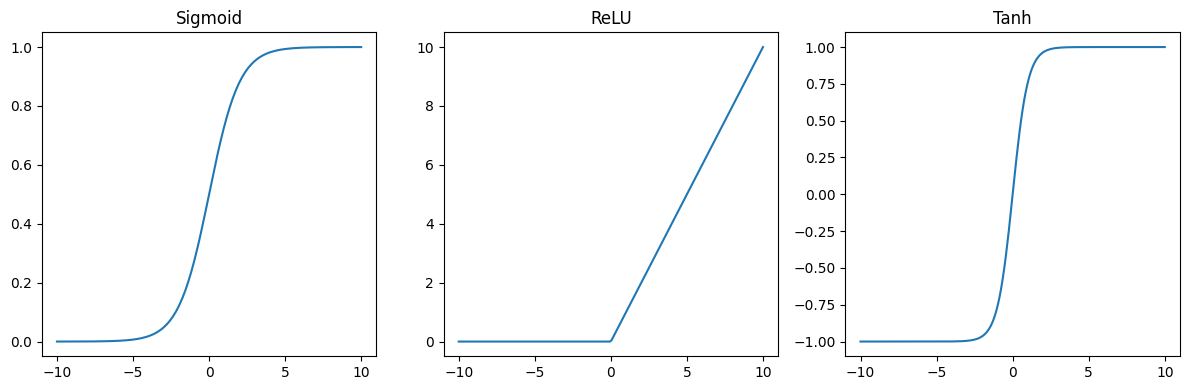

In [2]:
# Question 7:
# Implement and visualize Sigmoid, ReLU, and Tanh
# activation functions using Matplotlib.

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,200)

sigmoid = 1/(1+np.exp(-x))
relu = np.maximum(0,x)
tanh = np.tanh(x)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(x,sigmoid)
plt.title("Sigmoid")

plt.subplot(1,3,2)
plt.plot(x,relu)
plt.title("ReLU")

plt.subplot(1,3,3)
plt.plot(x,tanh)
plt.title("Tanh")

plt.tight_layout()
plt.show()

In [3]:
# Question 8:
# Use Keras to build and train a simple multilayer neural
# network on the MNIST digits dataset.
# Print the training accuracy.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Training Accuracy:", history.history['accuracy'][-1])
print("Test Accuracy:", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9210 - loss: 0.2709 - val_accuracy: 0.9588 - val_loss: 0.1394
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.1134 - val_accuracy: 0.9699 - val_loss: 0.0963
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9772 - loss: 0.0764 - val_accuracy: 0.9717 - val_loss: 0.0965
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9809 - loss: 0.0594 - val_accuracy: 0.9722 - val_loss: 0.1013
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0459 - val_accuracy: 0.9738 - val_loss: 0.0927
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0891
Training Accuracy: 0.9851458072662354
Test Accuracy: 0.9736999869346619


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8178 - loss: 0.5124 - val_accuracy: 0.8521 - val_loss: 0.4136
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8617 - loss: 0.3796 - val_accuracy: 0.8597 - val_loss: 0.3906
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8758 - loss: 0.3398 - val_accuracy: 0.8696 - val_loss: 0.3596
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8821 - loss: 0.3166 - val_accuracy: 0.8758 - val_loss: 0.3485
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8895 - loss: 0.3001 - val_accuracy: 0.8746 - val_loss: 0.3467
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8940 - loss: 0.2848 - val_accuracy: 0.8854 - val_loss: 0.3222
Epoch 7/10
1500/1500 ━━━━━━━━━━━

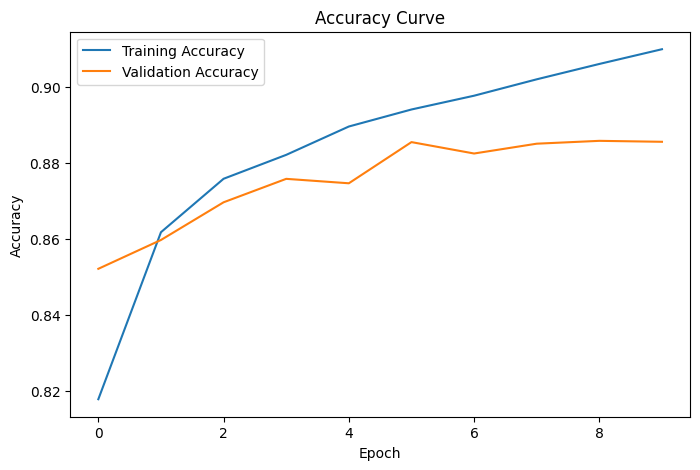

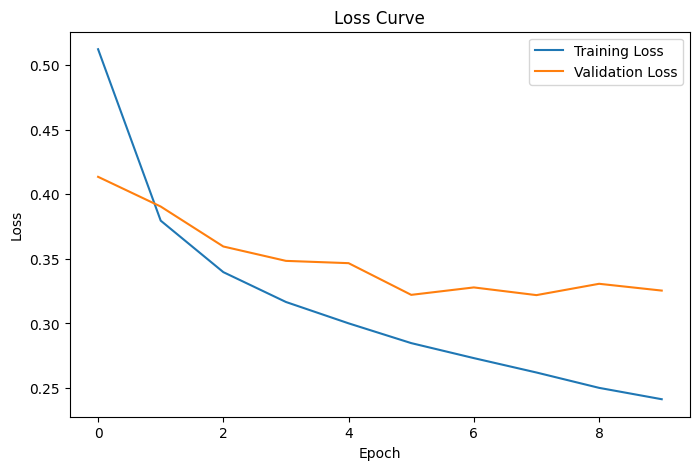

In [4]:
# Question 9:
# Visualize the loss and accuracy curves for a neural network
# model trained on the Fashion MNIST dataset.
# Interpret the training behavior.

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

In [5]:
# Question 10:
# You are working on a project for a bank that wants to automatically
# detect fraudulent transactions.
#
# Design a deep learning model, choose suitable activation and loss
# functions, explain how to train and evaluate it considering class
# imbalance, select an optimizer, and prevent overfitting.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(30,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)